### Import Required Libraries

In [172]:
from sklearn.metrics import roc_auc_score
import torch
import torch_geometric
import torch_sparse
import torch_scatter

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("PyG extensions working")

Torch: 2.7.1+cu118
CUDA: True
PyG extensions working


In [173]:
import torch
print(torch.__version__)

2.7.1+cu118


In [174]:
import torch

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.7.1+cu118
CUDA available: True
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [175]:
import torch
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [176]:
import torch
import torch_geometric

print(torch.__version__)
print("PyG working correctly")

2.7.1+cu118
PyG working correctly


In [177]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import HeteroConv, SAGEConv
from sklearn.metrics import roc_auc_score

In [178]:
import torch

data = torch.load("data/fraud_graph.pt", weights_only=False)

print("Loaded graph:",data)

Loaded graph: HeteroData(
  account={
    x=[179590, 7],
    num_nodes=179590,
  },
  device={
    x=[99473, 1],
    num_nodes=99473,
  },
  ip={
    x=[99999, 1],
    num_nodes=99999,
  },
  location={ num_nodes=8 },
  merchant={ num_nodes=8 },
  (account, transaction, account)={
    edge_index=[2, 100000],
    edge_label=[100000],
    edge_attr=[100000, 1],
  },
  (account, uses_device, device)={ edge_index=[2, 100000] },
  (account, uses_ip, ip)={ edge_index=[2, 100000] },
  (account, located_at, location)={ edge_index=[2, 100000] },
  (account, purchases, merchant)={ edge_index=[2, 100000] }
)


In [179]:
edge_index = data["account","transaction","account"].edge_index
edge_label = data["account","transaction","account"].edge_label

In [180]:
import numpy as np
from sklearn.model_selection import train_test_split

num_edges = edge_label.shape[0]
indices = np.arange(num_edges)

In [181]:
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=edge_label,
    random_state=42
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.15,
    stratify=edge_label[train_idx],
    random_state=42
)

In [182]:
import torch

data["account","transaction","account"].train_idx = torch.tensor(train_idx)
data["account","transaction","account"].val_idx = torch.tensor(val_idx)
data["account","transaction","account"].test_idx = torch.tensor(test_idx)

### Add Embeddings for Nodes Without Features

Our graph only has features for account nodes.

Other nodes need embeddings.

In [183]:
num_accounts = data["account"].num_nodes
num_devices = data["device"].num_nodes
num_ips = data["ip"].num_nodes
num_locations = data["location"].num_nodes
num_merchants = data["merchant"].num_nodes

### Define the Heterogeneous GNN

In [184]:
class FraudGNN(torch.nn.Module):

    def __init__(self, hidden_channels):

        super().__init__()

        self.location_emb = torch.nn.Embedding(num_locations, hidden_channels)
        self.merchant_emb = torch.nn.Embedding(num_merchants, hidden_channels)

        self.conv1 = HeteroConv({
            ('account','transaction','account'): SAGEConv((-1,-1), hidden_channels),
            ('account','uses_device','device'): SAGEConv((-1,-1), hidden_channels),
            ('account','uses_ip','ip'): SAGEConv((-1,-1), hidden_channels),
            ('account','located_at','location'): SAGEConv((-1,-1), hidden_channels),
            ('account','purchases','merchant'): SAGEConv((-1,-1), hidden_channels)
        })

        self.conv2 = HeteroConv({
            ('account','transaction','account'): SAGEConv((-1,-1), hidden_channels),
            ('account','uses_device','device'): SAGEConv((-1,-1), hidden_channels),
            ('account','uses_ip','ip'): SAGEConv((-1,-1), hidden_channels),
            ('account','located_at','location'): SAGEConv((-1,-1), hidden_channels),
            ('account','purchases','merchant'): SAGEConv((-1,-1), hidden_channels)
        })
       

    def forward(self, data):

        x_dict = {
            "account": data["account"].x,
            "device": data["device"].x,
            "ip": data["ip"].x,
            "location": self.location_emb.weight,
            "merchant": self.merchant_emb.weight
        }

        edge_index_dict = data.edge_index_dict

        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {k: F.relu(v) for k,v in x_dict.items()}
        x_dict = {k: F.dropout(v, p=0.3, training=self.training) for k,v in x_dict.items()}

        x_dict = self.conv2(x_dict, edge_index_dict)
        x_dict = {k: F.relu(v) for k,v in x_dict.items()}
        x_dict = {k: F.dropout(v, p=0.3, training=self.training) for k,v in x_dict.items()}

        return x_dict

### Edge Fraud Classifier

In [185]:
class EdgeClassifier(torch.nn.Module):

    def __init__(self, hidden_channels):
        super().__init__()

        self.lin1 = torch.nn.Linear(hidden_channels*2 + 1, hidden_channels)
        self.lin2 = torch.nn.Linear(hidden_channels,1)

    def forward(self, z_src, z_dst, edge_attr):

        h = torch.cat([z_src, z_dst, edge_attr], dim=1)

        h = F.relu(self.lin1(h))

        return self.lin2(h).view(-1)

### Initialize Model

In [186]:
hidden = 64


gnn = FraudGNN(hidden).to(device)
classifier = EdgeClassifier(hidden).to(device)

optimizer = torch.optim.Adam(
    list(gnn.parameters()) + list(classifier.parameters()),
    lr=0.001,weight_decay=1e-4
)

### Training Loop LinkNeighborLoader

In [187]:
from torch_geometric.loader import LinkNeighborLoader

In [188]:
edge_index = data["account","transaction","account"].edge_index
edge_label = data["account","transaction","account"].edge_label

In [189]:
train_loader = LinkNeighborLoader(
    data,
    num_neighbors=[10,10],
    edge_label_index=(
        ("account","transaction","account"),
        edge_index[:, data["account","transaction","account"].train_idx]
    ),
    edge_label=edge_label[data["account","transaction","account"].train_idx],
    batch_size=2048,
    shuffle=True
)

In [190]:
test_loader = LinkNeighborLoader(
    data,
    num_neighbors=[10,10],
    edge_label_index=(
        ("account","transaction","account"),
        edge_index[:, data["account","transaction","account"].test_idx]
    ),
    edge_label=edge_label[data["account","transaction","account"].test_idx],
    batch_size=2048,
    shuffle=False
)

In [191]:
for epoch in range(20):

    gnn.train()
    classifier.train()
    total_loss = 0
    all_labels = batch["account","transaction","account"].edge_label.float()

    pos_weight = ((len(all_labels)-all_labels.sum())/all_labels.sum()).to(device)
    for batch in train_loader:

        batch = batch.to(device)   # ADD THIS LINE

        optimizer.zero_grad()

        x_dict = gnn(batch)

        z = x_dict["account"]

        src = batch["account","transaction","account"].edge_label_index[0]
        dst = batch["account","transaction","account"].edge_label_index[1]

        edge_attr = batch["account","transaction","account"].edge_attr[:src.shape[0]]

        pred = classifier(z[src], z[dst], edge_attr)

        labels = batch["account","transaction","account"].edge_label.float()

        loss = F.binary_cross_entropy_with_logits(
            pred,
            labels,
            pos_weight=pos_weight
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss {total_loss:.4f}")
    torch.save({
        "gnn":gnn.state_dict(),
        "classifier":classifier.state_dict()
     }, "fraud_gnn_model.pt")
    print("Model Saved")

Epoch 0 Loss 32.3625
Model Saved
Epoch 1 Loss 4.0352
Model Saved
Epoch 2 Loss 1.4387
Model Saved
Epoch 3 Loss 1.0276
Model Saved
Epoch 4 Loss 0.9089
Model Saved
Epoch 5 Loss 0.9642
Model Saved
Epoch 6 Loss 0.8980
Model Saved
Epoch 7 Loss 0.7859
Model Saved
Epoch 8 Loss 0.8503
Model Saved
Epoch 9 Loss 0.7073
Model Saved
Epoch 10 Loss 0.7015
Model Saved
Epoch 11 Loss 0.6057
Model Saved
Epoch 12 Loss 0.6961
Model Saved
Epoch 13 Loss 0.9068
Model Saved
Epoch 14 Loss 0.9687
Model Saved
Epoch 15 Loss 0.6598
Model Saved
Epoch 16 Loss 0.6452
Model Saved
Epoch 17 Loss 0.6518
Model Saved
Epoch 18 Loss 0.6938
Model Saved
Epoch 19 Loss 0.6303
Model Saved


### Evaluate Model

In [193]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 508.0 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.1 MB 508.0 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.1 MB 508.0 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.1 MB 459.5 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.1 MB 459.5 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.1 MB 459.5 kB/s eta 0:00:16
   ----- ---------------------------------- 1.0/8

Hetero GNN ROC-AUC: 0.9995863956452317

Classification Metrics
----------------------
Accuracy : 0.9964666666666666
Precision: 0.834375
Recall   : 1.0
F1 Score : 0.909710391822828

Confusion Matrix
----------------
[[14680    53]
 [    0   267]]

Detailed Classification Report
--------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14733
           1       0.83      1.00      0.91       267

    accuracy                           1.00     15000
   macro avg       0.92      1.00      0.95     15000
weighted avg       1.00      1.00      1.00     15000


Precision-Recall AUC: 0.9784703887504251


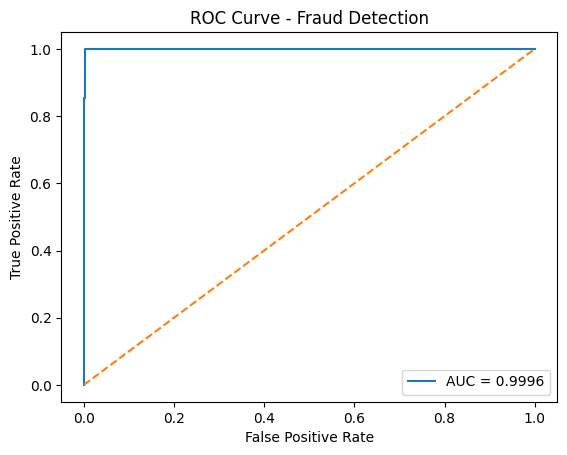

In [196]:
from sklearn.metrics import(
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    average_precision_score
)
preds = []
labels_all = []

gnn.eval()
classifier.eval()

for batch in test_loader:
    batch = batch.to(device)
    with torch.no_grad():

        x_dict = gnn(batch)

        z = x_dict["account"]

        src = batch["account","transaction","account"].edge_label_index[0]
        dst = batch["account","transaction","account"].edge_label_index[1]

        edge_attr = batch["account","transaction","account"].edge_attr[:src.shape[0]]

        pred = classifier(z[src], z[dst], edge_attr).sigmoid()

        preds.append(pred.cpu())
        labels_all.append(batch["account","transaction","account"].edge_label.cpu())

preds = torch.cat(preds).numpy()
labels_all = torch.cat(labels_all).numpy()

roc = roc_auc_score(labels_all, preds)
pred_binary = (preds > 0.5).astype(int)
print("Hetero GNN ROC-AUC:", roc)
accuracy = accuracy_score(labels_all, pred_binary)
precision = precision_score(labels_all, pred_binary)
recall = recall_score(labels_all, pred_binary)
f1 = f1_score(labels_all, pred_binary)

print("\nClassification Metrics")
print("----------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

cm = confusion_matrix(labels_all, pred_binary)

print("\nConfusion Matrix")
print("----------------")
print(cm)

print("\nDetailed Classification Report")
print("--------------------------------")
print(classification_report(labels_all, pred_binary))

pr_auc = average_precision_score(labels_all, preds)

print("\nPrecision-Recall AUC:", pr_auc)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(labels_all, preds)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fraud Detection")
plt.legend()
plt.show()